# **Importing Data**, **Libraries**, & **Initial Checks**

In [ ]:
# Installing and importing libraries
install.packages("googledrive")
install.packages("readr")
install.packages("plotly")
install.packages("dplyr")
install.packages("tidyr")
install.packages("factoextra")
install.packages("FactoMineR")
install.packages("cluster")
install.packages("clValid")
install.packages("NbClust")

library(googledrive)
library(readr)
library(dplyr)
library(tidyr)
library(cluster)
library(factoextra)
library(FactoMineR)
library(cluster)
library(ggplot2)
library(plotly)
library(dplyr)
library(clValid)
library(NbClust)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘plyr

In [ ]:
drive_auth()
drive_ls()
drive_download(file = "Colab Notebooks/Final Project/hour_train_final_clean.csv", overwrite = TRUE)
drive_download(file = "Colab Notebooks/Final Project/hour_train_ts.csv", overwrite = TRUE)

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=d2e8f5fe5e71f2d845c2ad3049457328&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQVZHelIxREVkcV8wS2Q3UlphQ18wVHItMlg1NG9ydDBnbV9hcWVjVS1qaDhtR1RiN3FMaXFYT3NTa0J1MlBuZlEtUmVaQSIsInN0YXRlIjoiZDJlOGY1ZmU1ZTcxZjJkODQ1YzJhZDMwNDk0NTczMjgifQ==


ERROR while rich displaying an object: Error in rbind(parts$upper, chars$ellip_v, parts$lower, deparse.level = 0L): number of columns of matrices must match (see arg 3)

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         retu

In [ ]:
# Importing the data
train_final_clean <- read_csv("hour_train_final_clean.csv")
train_ts <- read_csv("hour_train_ts.csv")

Rows: 8406 Columns: 41
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (41): year, month, hour, season, holiday, weekday, workingday, weathersi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8406 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (15): season, yr, mnth, hr, holiday, weekday, workingday, weathersit, t...
date  (1): dteday

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Load and prepare data
df <- train_final_clean

In [ ]:
str(df)

spc_tbl_ [8,406 × 41] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ year             : num [1:8406] 2011 2011 2011 2011 2011 ...
 $ month            : num [1:8406] 1 1 1 1 1 1 1 1 1 1 ...
 $ hour             : num [1:8406] 0 1 2 3 4 5 6 7 8 9 ...
 $ season           : num [1:8406] 1 1 1 1 1 1 1 1 1 1 ...
 $ holiday          : num [1:8406] 0 0 0 0 0 0 0 0 0 0 ...
 $ weekday          : num [1:8406] 6 6 6 6 6 6 6 6 6 6 ...
 $ workingday       : num [1:8406] 0 0 0 0 0 0 0 0 0 0 ...
 $ weathersit       : num [1:8406] 1 1 1 1 1 2 1 1 1 1 ...
 $ temp             : num [1:8406] 0.24 0.22 0.22 0.24 0.24 0.24 0.22 0.2 0.24 0.32 ...
 $ atemp            : num [1:8406] 0.288 0.273 0.273 0.288 0.288 ...
 $ hum              : num [1:8406] 0.81 0.8 0.8 0.75 0.75 0.75 0.8 0.86 0.75 0.76 ...
 $ windspeed        : num [1:8406] 0 0 0 0 0 0.0896 0 0 0 0 ...
 $ cnt              : num [1:8406] 16 40 32 13 1 1 2 3 8 14 ...
 $ hour_sin         : num [1:8406] 0 0.259 0.5 0.707 0.866 ...
 $ hour_cos         : num [

In [ ]:
# Checking the shape of the dataset
dim(train_final_clean)

[1] 8406   41

In [ ]:
# Check for duplicate rows
duplicate_rows <- duplicated(df)
num_duplicate_rows <- sum(duplicate_rows)

if (num_duplicate_rows > 0) {
  print(paste("Number of duplicate rows found:", num_duplicate_rows))

  # Display the duplicate rows
  display(df[duplicate_rows, ])
} else {
  print("No duplicate rows found")
}

[1] "No duplicate rows found"




---



# **Descriptive Analysis**: Part 3

In [ ]:
# Select features for FAMD - mixed types
categorical_features <- c('year', 'month', 'season', 'weathersit', 'holiday', 'workingday', 'weekday')
numerical_features <- c('temp', 'atemp', 'hum', 'windspeed', 'cnt', 'hour')

# Add some engineered features if available
engineered_features <- c()
if('rolling_mean_24h' %in% names(df)) engineered_features <- c(engineered_features, 'rolling_mean_24h')

famd_features <- c(categorical_features, numerical_features, engineered_features)

# Convert categorical features to factors and ensure unique levels across features
for(feature in categorical_features) {
  if(feature %in% names(df)) {
    df[[feature]] <- as.factor(df[[feature]])
    # Prefix the feature name to each level to make them unique
    levels(df[[feature]]) <- paste(feature, levels(df[[feature]]), sep = "_")
  }
}

# Prepare data again
X_famd <- df[, famd_features]

# Remove constant features
constant_features <- sapply(X_famd, function(x) length(unique(x)) <= 1)
X_famd <- X_famd[, !constant_features]

print(paste("Features for FAMD:", length(famd_features)))
print(paste("Categorical:", length(categorical_features)))
print(paste("Numerical:", length(numerical_features)))
print(paste("Engineered:", length(engineered_features)))


# Ensure unique row names
rownames(X_famd) <- make.unique(as.character(1:nrow(X_famd)))

# Perform FAMD
print("Performing FAMD...")
famd_result <- FAMD(X_famd, ncp = 10, graph = FALSE)

# FAMD Summary
print("FAMD Results Summary:")
summary(famd_result)

[1] "Features for FAMD: 14"
[1] "Categorical: 7"
[1] "Numerical: 6"
[1] "Engineered: 1"


Warning message:
“Setting row names on a tibble is deprecated.”


[1] "Performing FAMD..."
[1] "FAMD Results Summary:"

Call:
FAMD(base = X_famd, ncp = 10, graph = FALSE) 


Eigenvalues
                      Dim.1  Dim.2  Dim.3  Dim.4  Dim.5  Dim.6  Dim.7  Dim.8
Variance              4.553  2.154  2.037  1.914  1.717  1.273  1.153  1.084
% of var.            14.686  6.948  6.571  6.174  5.540  4.105  3.720  3.498
Cumulative % of var. 14.686 21.634 28.204 34.378 39.918 44.023 47.743 51.241
                      Dim.9 Dim.10
Variance              1.081  1.046
% of var.             3.487  3.376
Cumulative % of var. 54.728 58.104

Individuals (the 10 first)
                     Dist    Dim.1    ctr   cos2    Dim.2    ctr   cos2  
1                |  6.176 | -3.667  0.035  0.353 |  0.478  0.001  0.006 |
2                |  6.109 | -3.661  0.035  0.359 |  0.529  0.002  0.007 |
3                |  6.050 | -3.630  0.034  0.360 |  0.539  0.002  0.008 |
4                |  5.942 | -3.532  0.033  0.353 |  0.662  0.002  0.012 |
5                |  5.901 | -3.511



---



* **Part 1**: FAMD **Visualization**

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


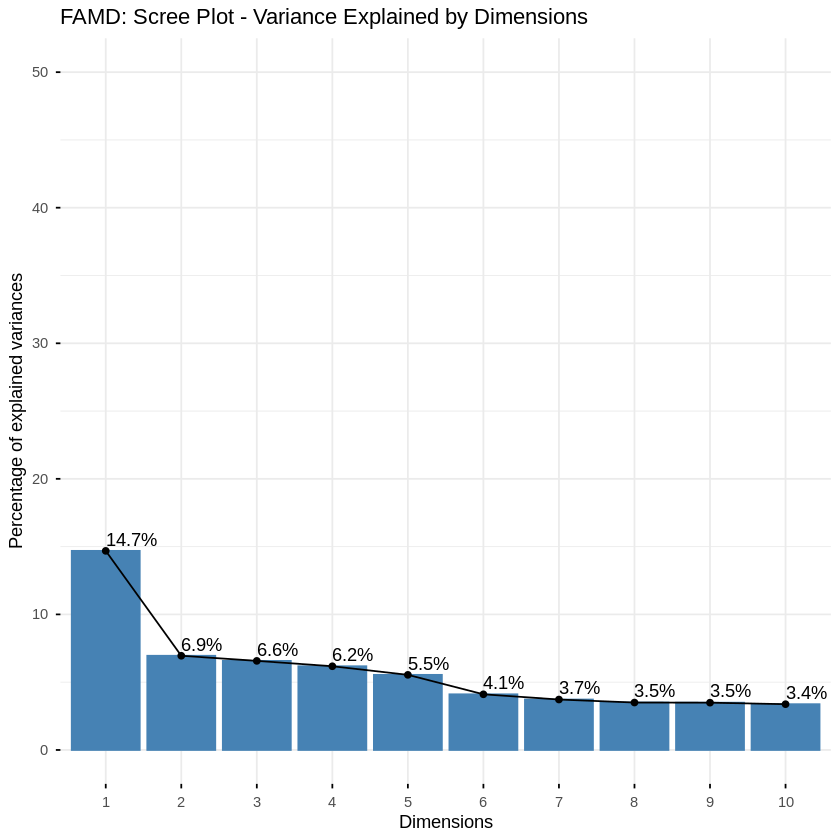

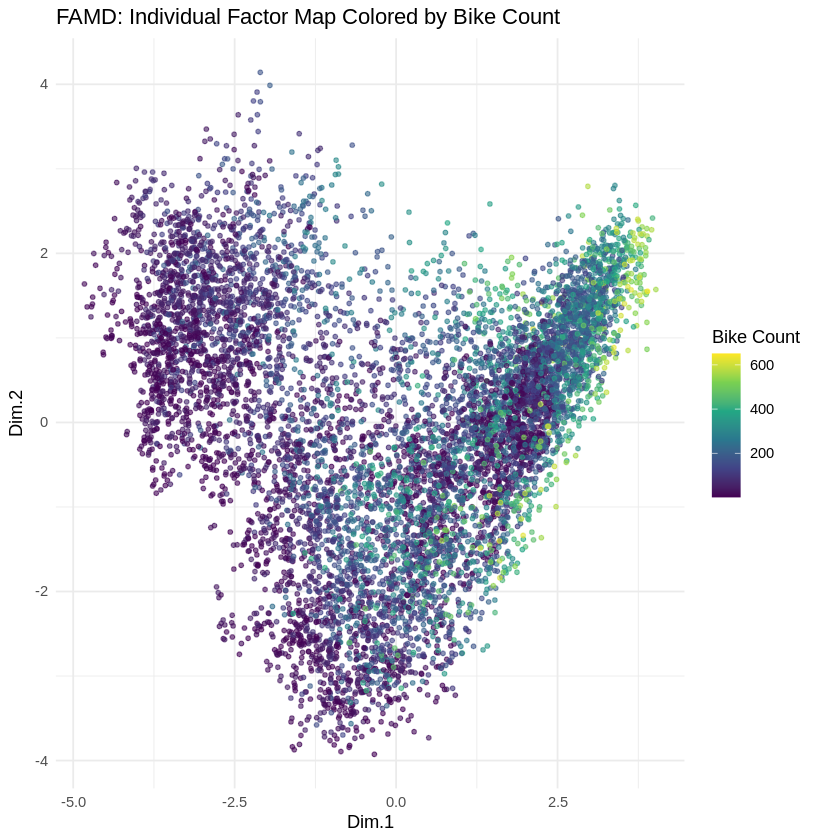

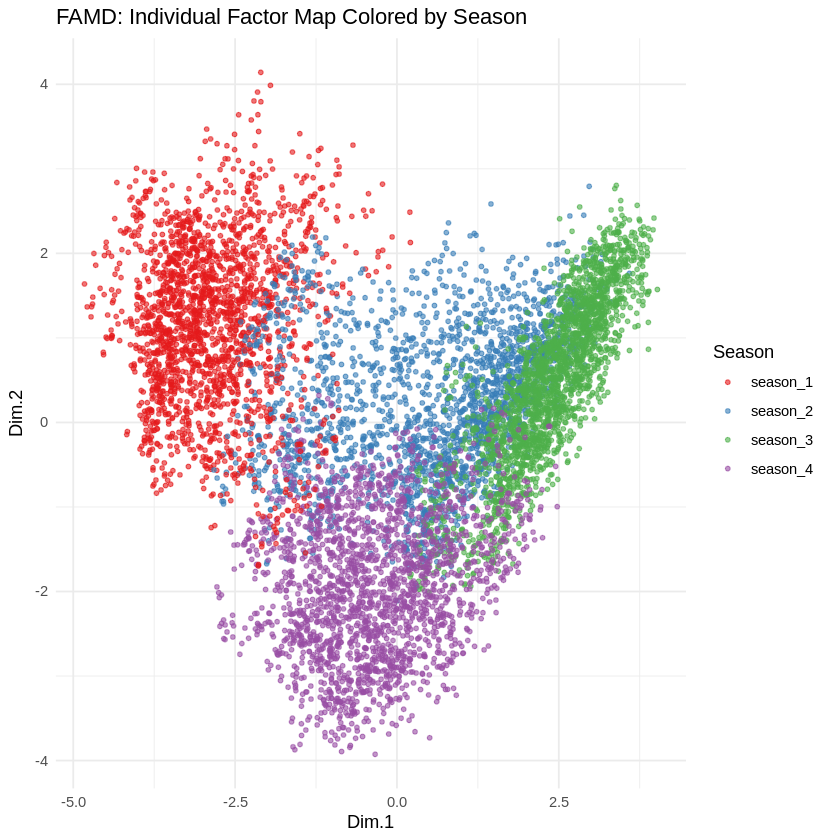

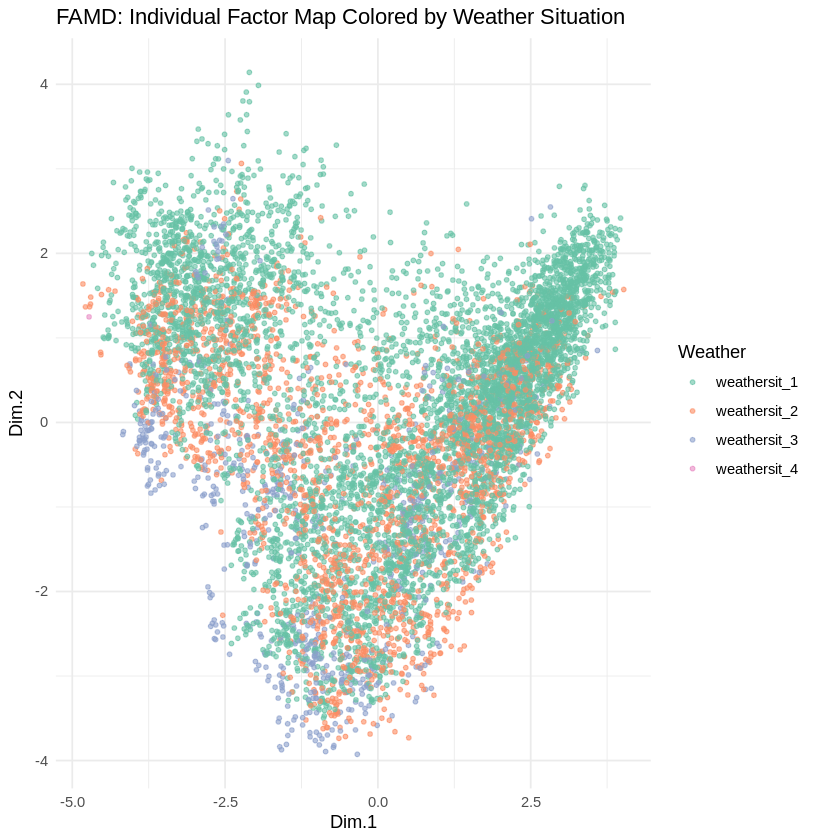

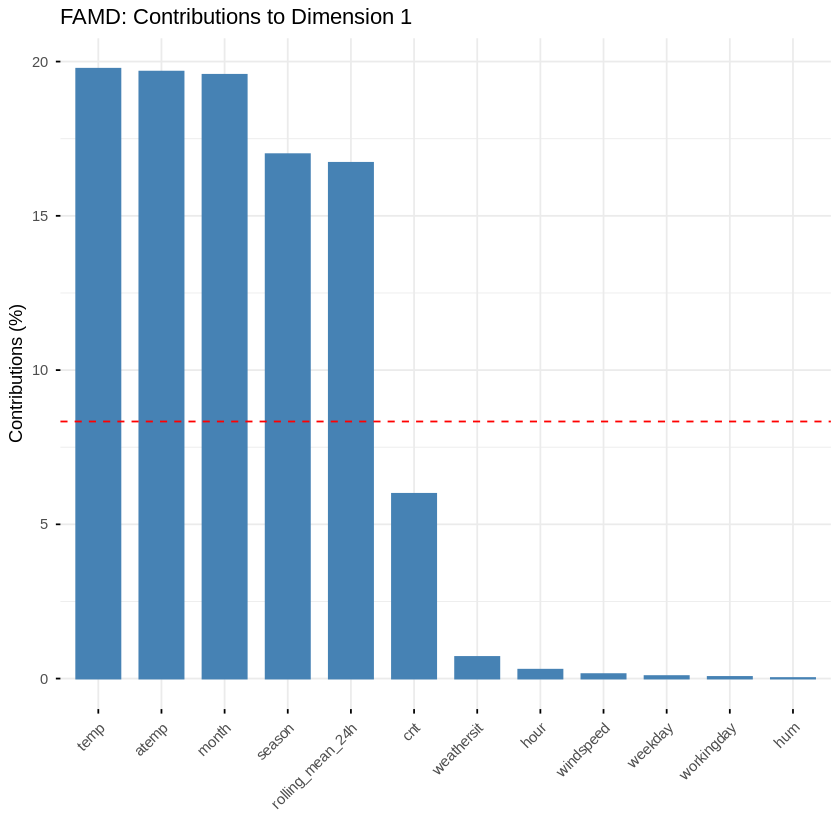

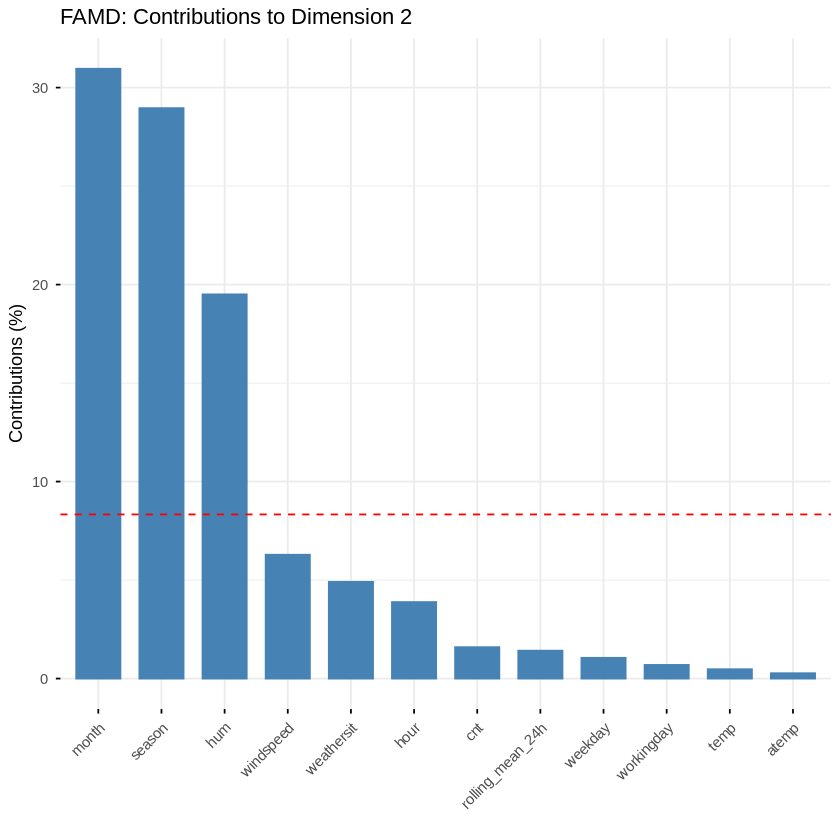

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”


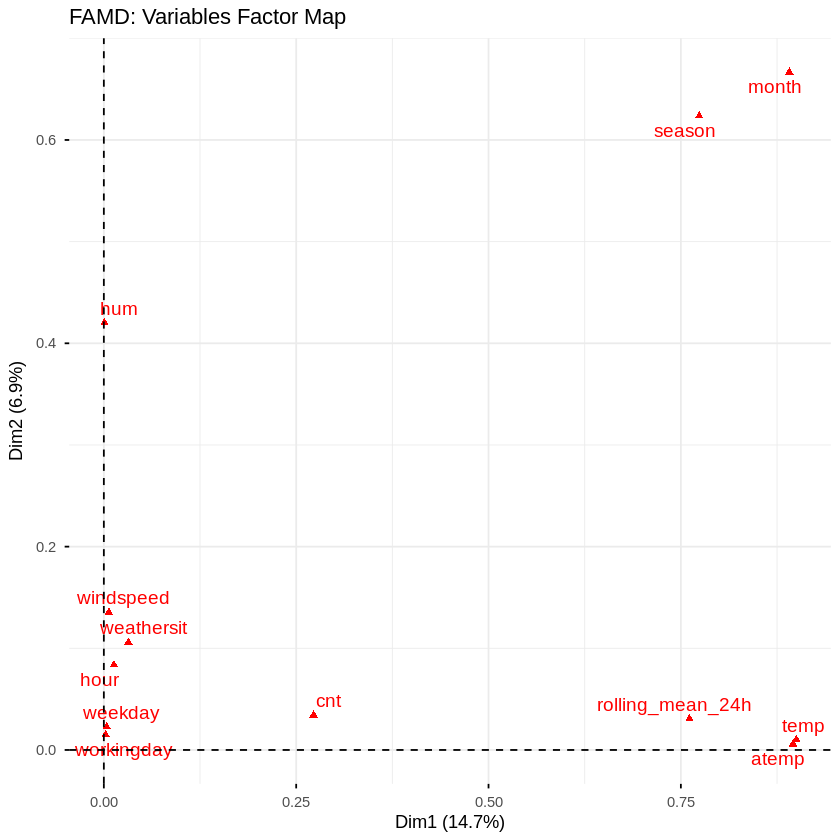

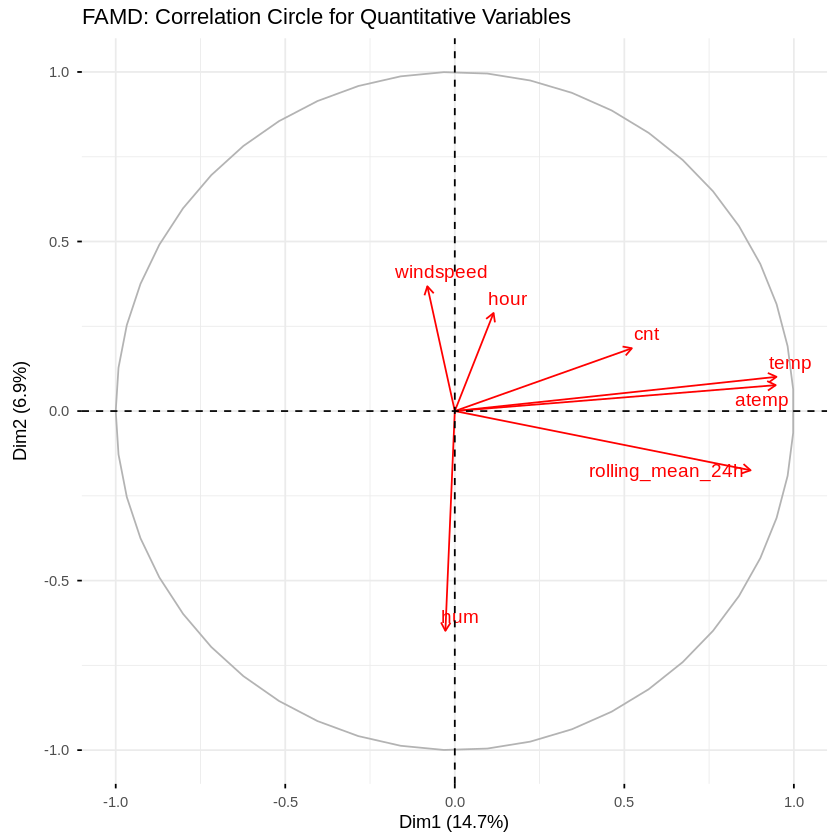

[1] "Top contributing variables to Dimension 1:"
            temp            atemp            month           season 
      19.7674953       19.6743288       19.5713375       16.9981055 
rolling_mean_24h              cnt       weathersit             hour 
      16.7183014        5.9888339        0.7007208        0.2870275 
       windspeed          weekday 
       0.1439899        0.0804683 
[1] "Top contributing variables to Dimension 2:"
           month           season              hum        windspeed 
       30.956578        28.957555        19.503454         6.286337 
      weathersit             hour              cnt rolling_mean_24h 
        4.911727         3.883109         1.592468         1.417181 
         weekday       workingday 
        1.053453         0.692760 


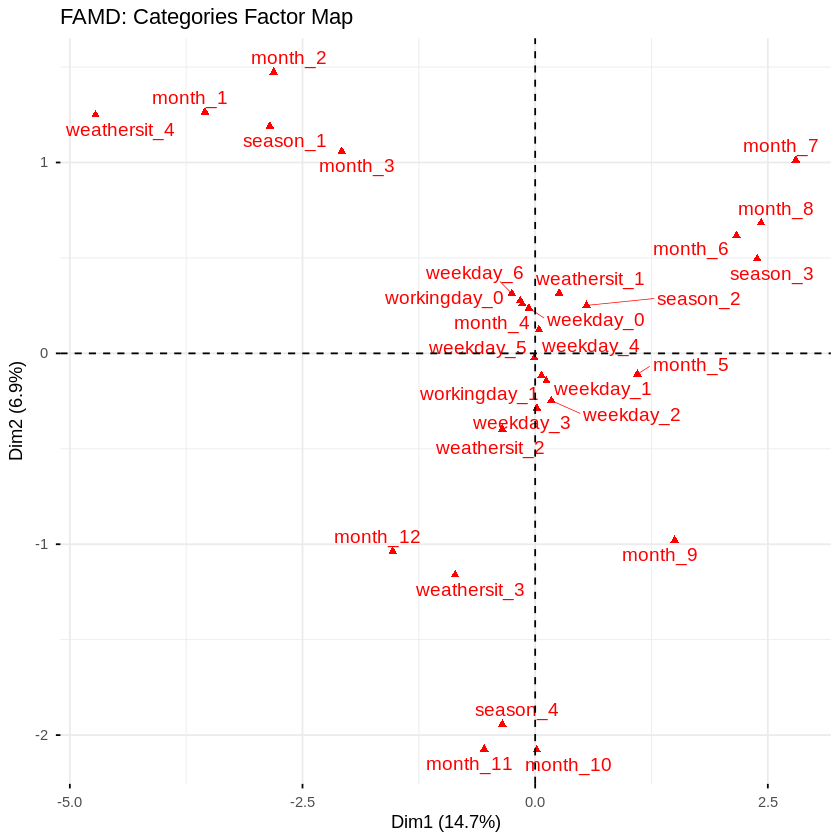

In [ ]:
# 1. Eigenvalues and Variance Explained
fviz_screeplot(famd_result, addlabels = TRUE, ylim = c(0, 50)) +
  ggtitle("FAMD: Scree Plot - Variance Explained by Dimensions")

# 2. Individual Factor Map colored by bike count
famd_scores <- as.data.frame(famd_result$ind$coord)
famd_scores$cnt <- df$cnt

ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = cnt)) +
  geom_point(alpha = 0.6, size = 1) +
  scale_color_viridis_c(name = "Bike Count") +
  ggtitle("FAMD: Individual Factor Map Colored by Bike Count") +
  theme_minimal()

# 3. Factor Map colored by season
famd_scores$season <- as.factor(df$season)

ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = season)) +
  geom_point(alpha = 0.6, size = 1) +
  scale_color_brewer(palette = "Set1", name = "Season") +
  ggtitle("FAMD: Individual Factor Map Colored by Season") +
  theme_minimal()

# 4. Factor Map colored by weather situation
famd_scores$weathersit <- as.factor(df$weathersit)

ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = weathersit)) +
  geom_point(alpha = 0.6, size = 1) +
  scale_color_brewer(palette = "Set2", name = "Weather") +
  ggtitle("FAMD: Individual Factor Map Colored by Weather Situation") +
  theme_minimal()

# 5. Variable Contributions
# Quantitative variables
fviz_contrib(famd_result, choice = "var", axes = 1, top = 15) +
  ggtitle("FAMD: Contributions to Dimension 1")

fviz_contrib(famd_result, choice = "var", axes = 2, top = 15) +
  ggtitle("FAMD: Contributions to Dimension 2")

# 6. Biplot (simplified)
fviz_famd_var(famd_result, repel = TRUE) +
  ggtitle("FAMD: Variables Factor Map")

# 7. Correlation Circle for Quantitative Variables
fviz_famd_var(famd_result, choice = "quanti.var", repel = TRUE) +
  ggtitle("FAMD: Correlation Circle for Quantitative Variables")

# 8. Categories Factor Map
fviz_famd_var(famd_result, choice = "quali.var", repel = TRUE) +
  ggtitle("FAMD: Categories Factor Map")

# 9. Detailed variable analysis
print("Top contributing variables to Dimension 1:")
dim1_contrib <- sort(famd_result$var$contrib[,1], decreasing = TRUE)
print(head(dim1_contrib, 10))

print("Top contributing variables to Dimension 2:")
dim2_contrib <- sort(famd_result$var$contrib[,2], decreasing = TRUE)
print(head(dim2_contrib, 10))



---



* **Part 2**: **Cluster Analysis** using FAMD **Factor Scores**

In [ ]:
# Use first 10 dimensions for clustering (capture most variance, nearly 55%)
n_dims <- min(10, ncol(famd_result$ind$coord))
cluster_data <- famd_result$ind$coord[, 1:n_dims]

**Approach 1**: The **30** Different **Validation Criteria** (e.g., Calinski–Harabasz (CH), Dunn, Silhouette, SD index, Ball, Hartigan, etc.)

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


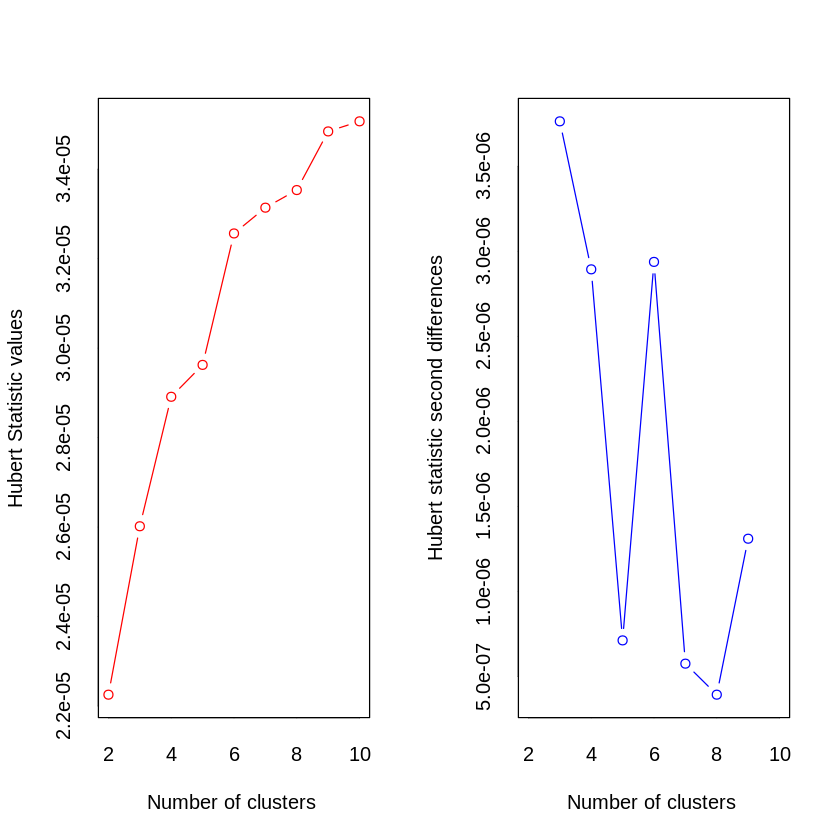

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 5 proposed 2 as the best number of clusters 
* 2 proposed 3 as the best number of clusters 
* 6 proposed 4 as the best number of clusters 
* 5 proposed 5 as the best number of clusters 
* 1 proposed 6 as the best number of clusters 
* 2 proposed 9 as the best number of clusters 
* 2 proposed 10 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  4 
 
 
******************************************************************* 


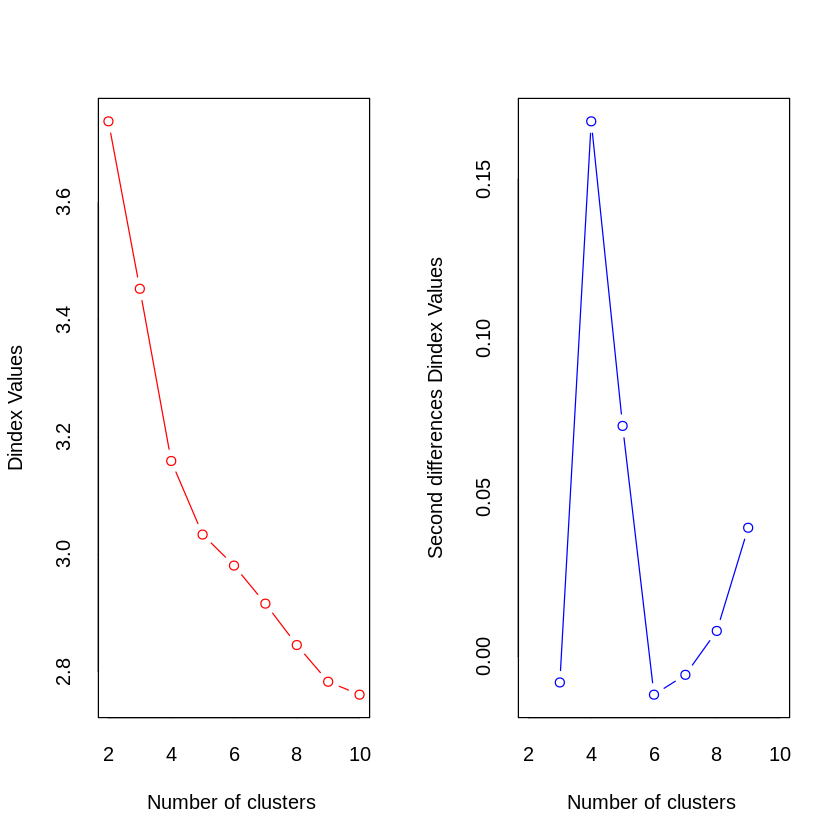

In [ ]:
nb <- NbClust(cluster_data, distance = "euclidean", min.nc = 2, max.nc = 10, method = "kmeans")

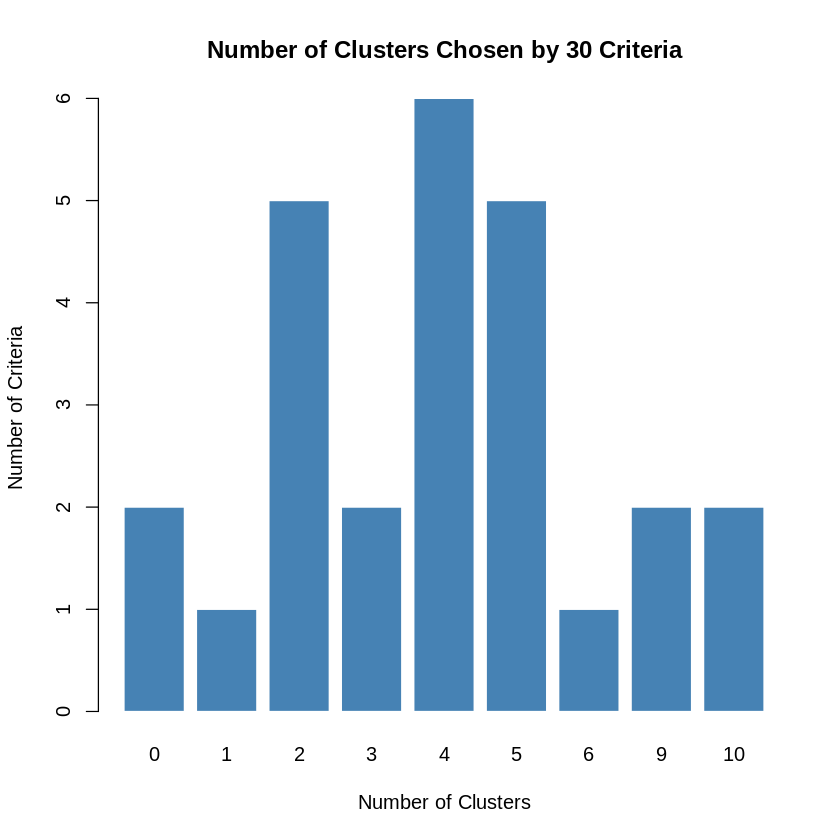

In [ ]:
barplot(table(nb$Best.n[1,]), xlab = "Number of Clusters", ylab = "Number of Criteria", main = "Number of Clusters Chosen by 30 Criteria", border = FALSE, col = "steelblue")



---



**Approach 2**: The **Elbow** Method

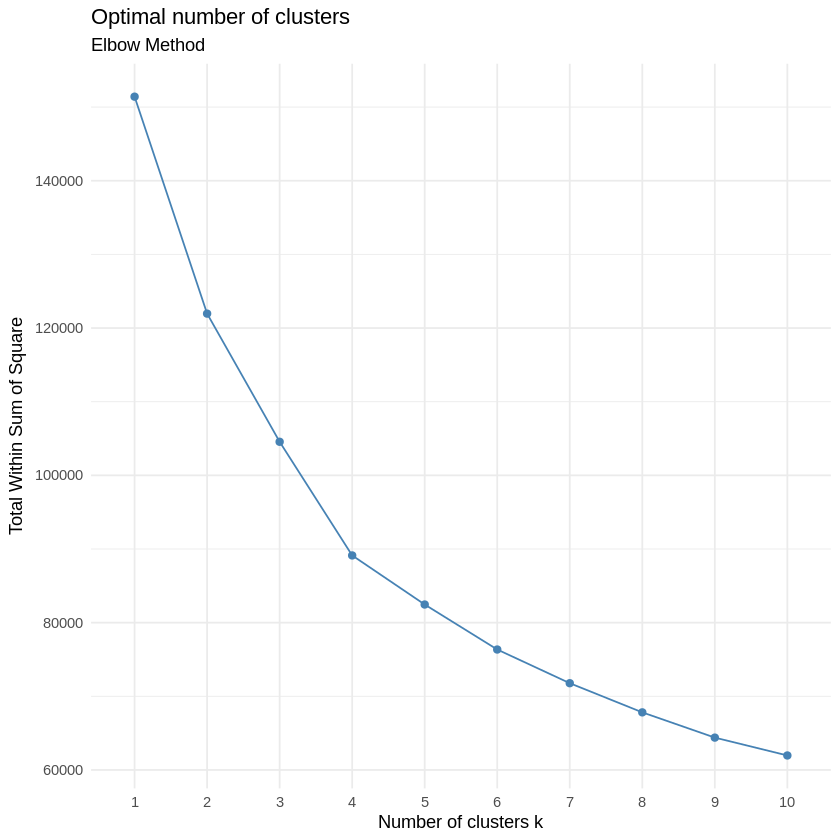

In [ ]:
custom_kmeans <- function(x, k) {
  set.seed(123)
  kmeans(x, centers = k, nstart = 25, iter.max = 100)
}

fviz_nbclust(cluster_data, FUNcluster = custom_kmeans, method = "wss") + labs(subtitle = "Elbow Method") + theme_minimal()



---



**Approach 3**: The **Silhouette** Method

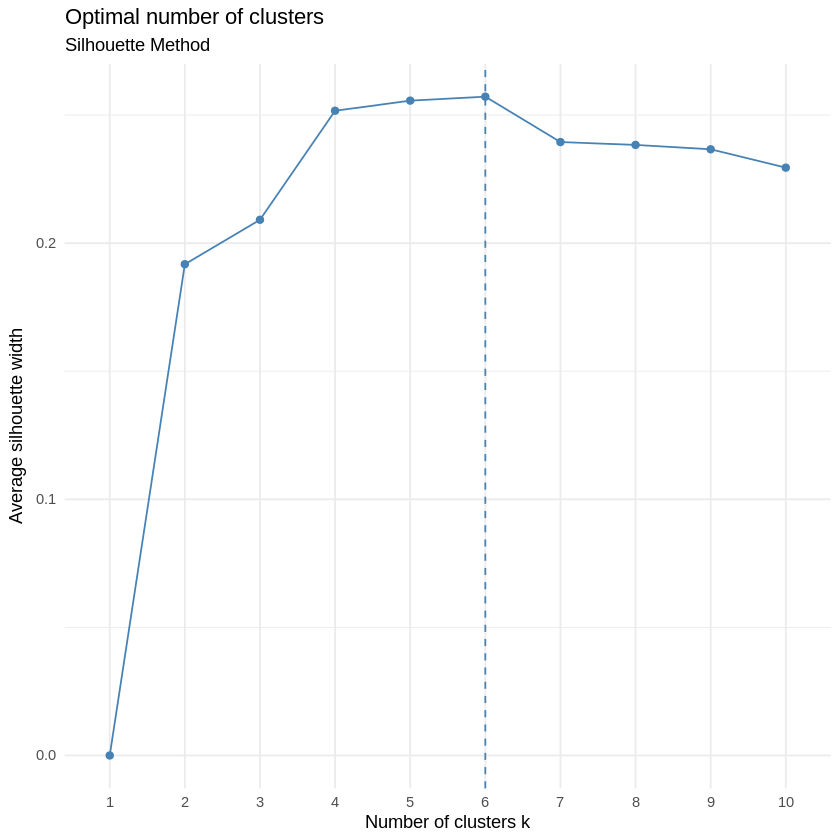

In [ ]:
fviz_nbclust(cluster_data, FUNcluster = custom_kmeans, method = "silhouette") + labs(subtitle = "Silhouette Method") + theme_minimal()



---



**Approach 4**: The **Gap Statistic** Method

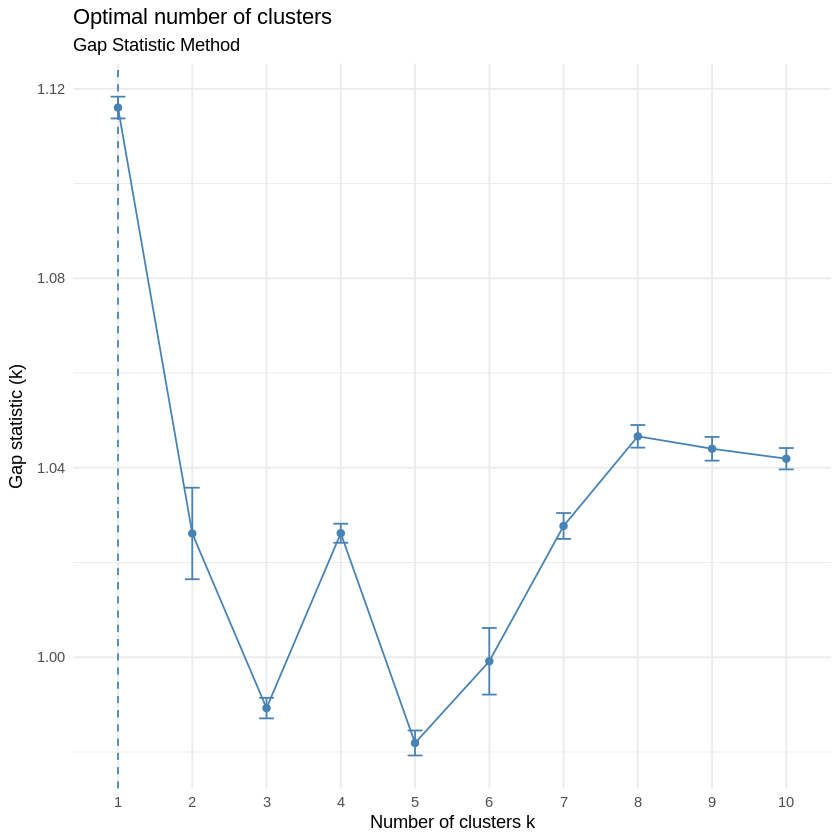

In [ ]:
set.seed(123)
fviz_nbclust(cluster_data, kmeans, method = "gap_stat", iter.max = 100, nboot = 100) + labs(subtitle = "Gap Statistic Method") + theme_minimal()



---



* **Part 3**: Final Clustering with **Optimal K**

In [ ]:
library(RColorBrewer)



Performing K-means clustering with K = 2 ...


📊 Analyzing cluster profiles...


Warning message:
“There were 4 warnings in `summarise()`.
The first warning was:
ℹ In argument: `dominant_season = as.numeric(names(which.max(table(season))))`.
ℹ In group 1: `cluster = 1`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.”


# A tibble: 2 × 10
  cluster     n percentage avg_bikes sd_bikes avg_temp avg_hum peak_hour
    <int> <int>      <dbl>     <dbl>    <dbl>    <dbl>   <dbl>     <dbl>
1       1  4091       48.7     195.     150.     0.657   0.649        17
2       2  4315       51.3      96.7     94.7    0.331   0.640         6
# ℹ 2 more variables: dominant_season <dbl>, dominant_weather <dbl>


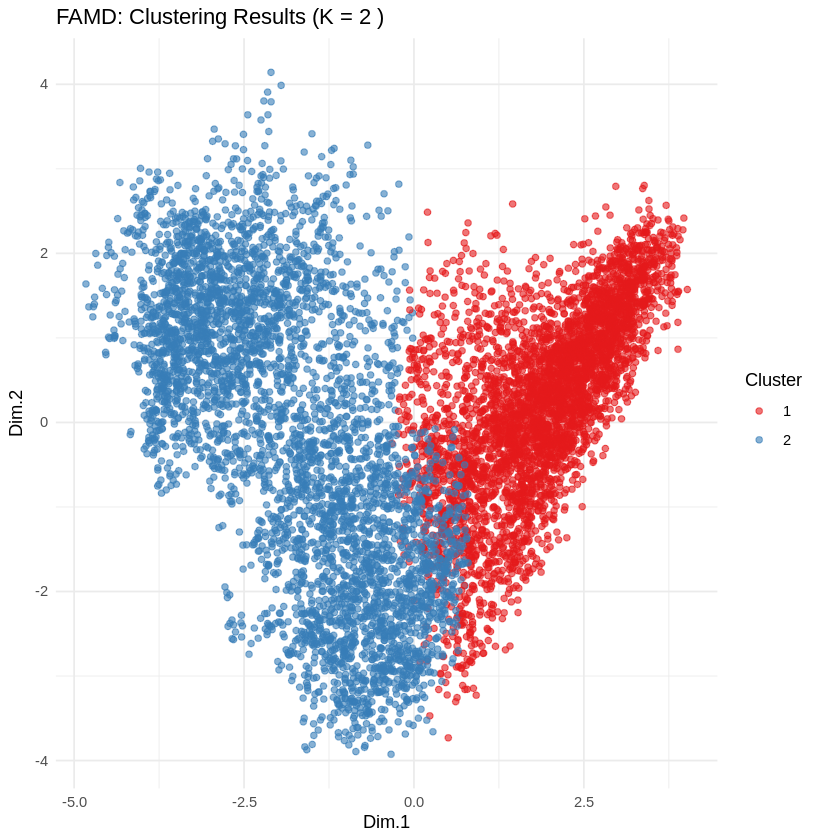

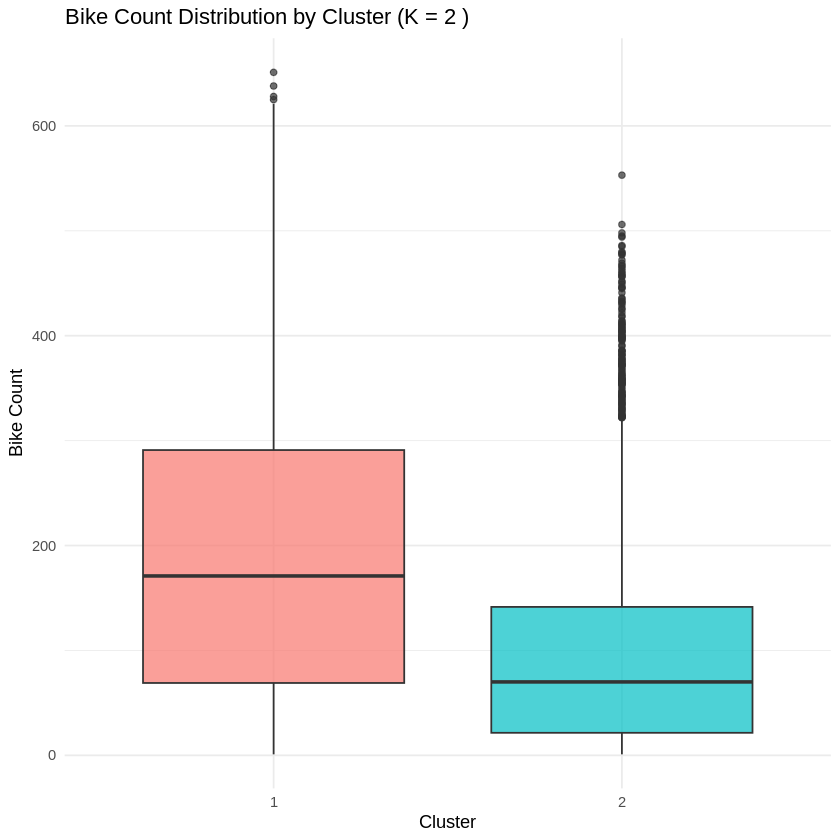

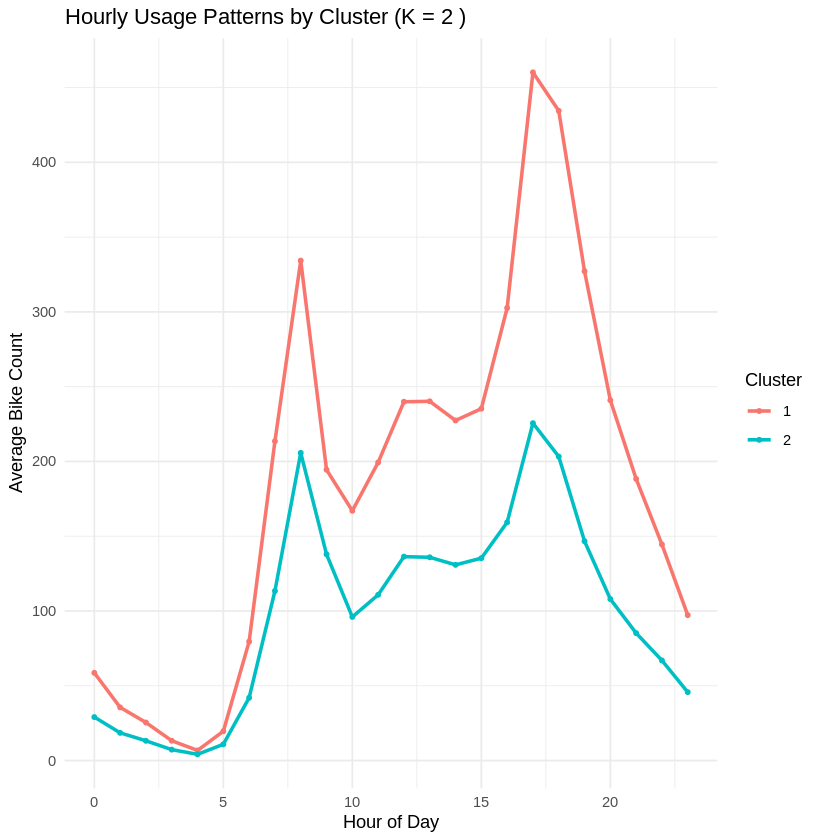



Performing K-means clustering with K = 4 ...


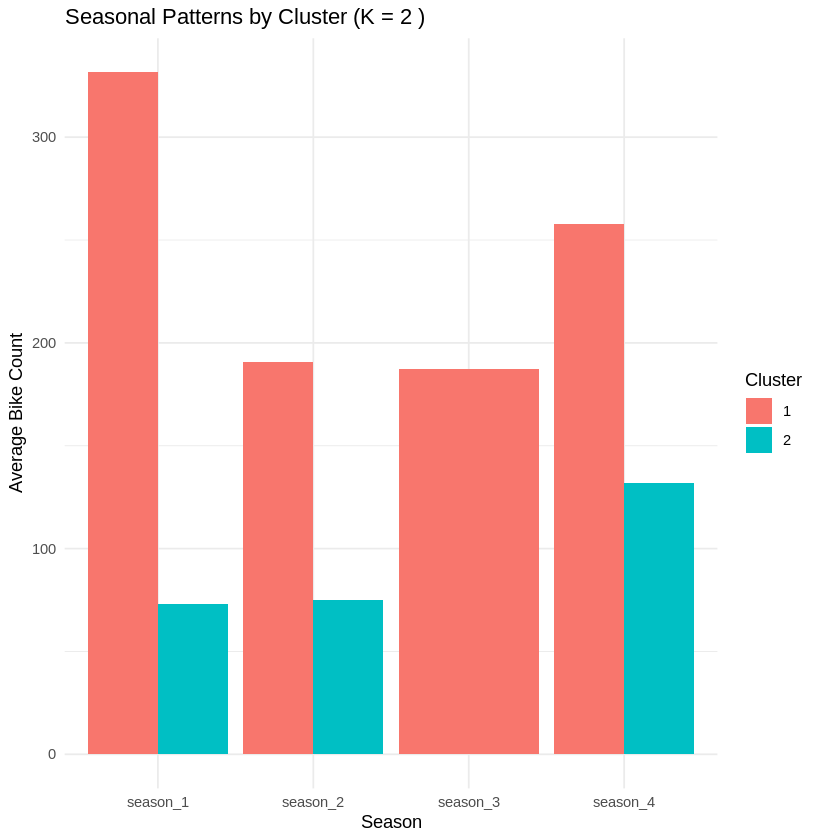



📊 Analyzing cluster profiles...


Warning message:
“There were 8 warnings in `summarise()`.
The first warning was:
ℹ In argument: `dominant_season = as.numeric(names(which.max(table(season))))`.
ℹ In group 1: `cluster = 1`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 7 remaining warnings.”


# A tibble: 4 × 10
  cluster     n percentage avg_bikes sd_bikes avg_temp avg_hum peak_hour
    <int> <int>      <dbl>     <dbl>    <dbl>    <dbl>   <dbl>     <dbl>
1       4  2252       26.8     191.     150.     0.700   0.644        13
2       1  1935       23.0     167.     142.     0.562   0.666        16
3       3  2005       23.9     148.     130.     0.419   0.699         8
4       2  2214       26.3      73.7     67.7    0.276   0.576        22
# ℹ 2 more variables: dominant_season <dbl>, dominant_weather <dbl>


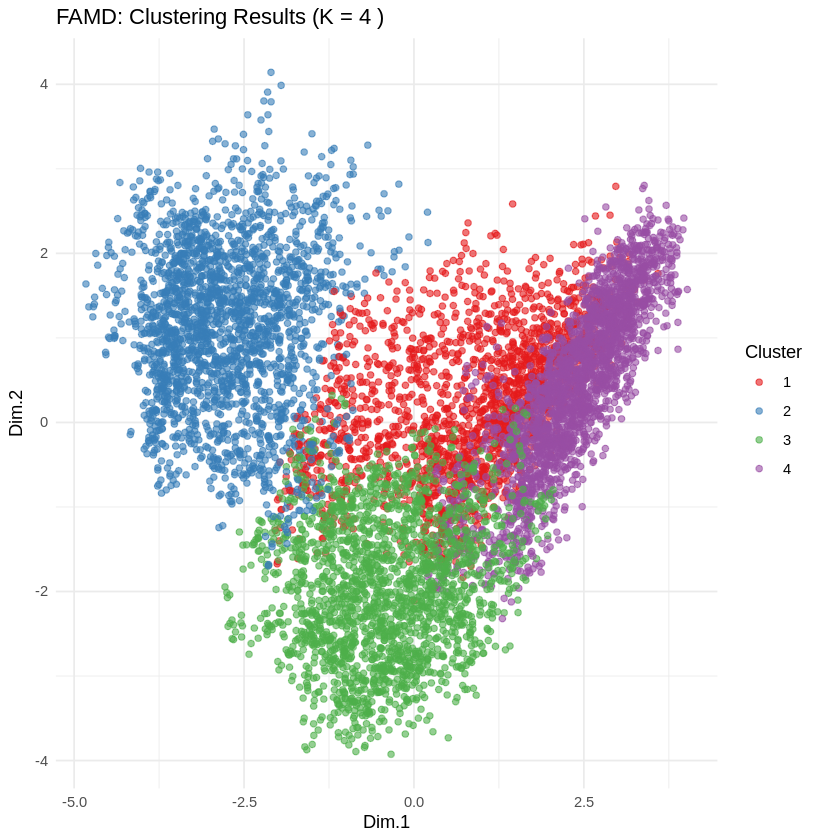

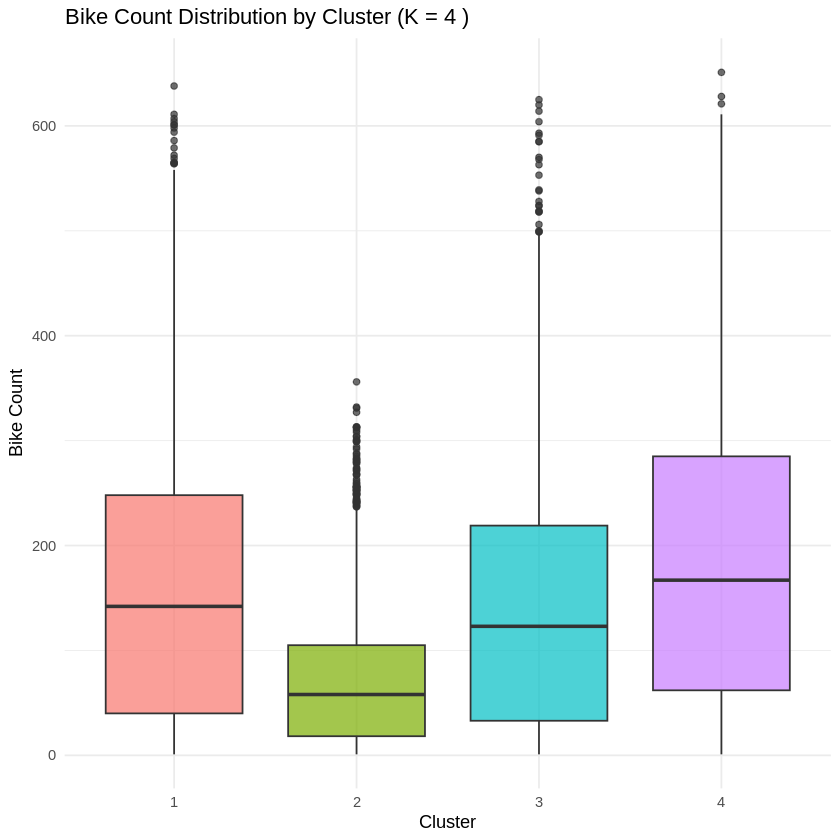

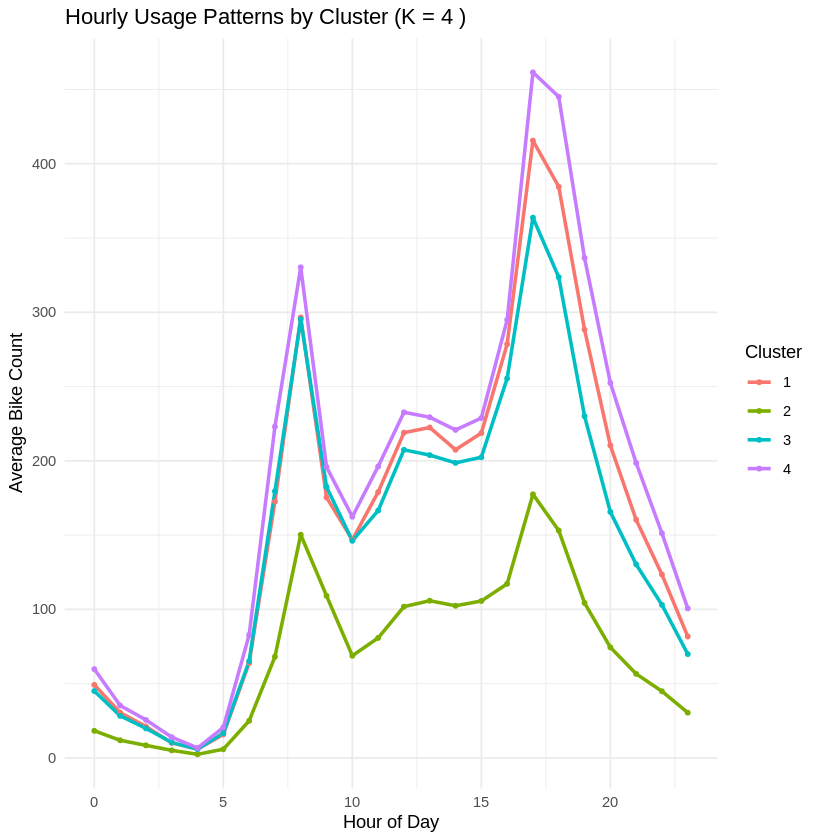

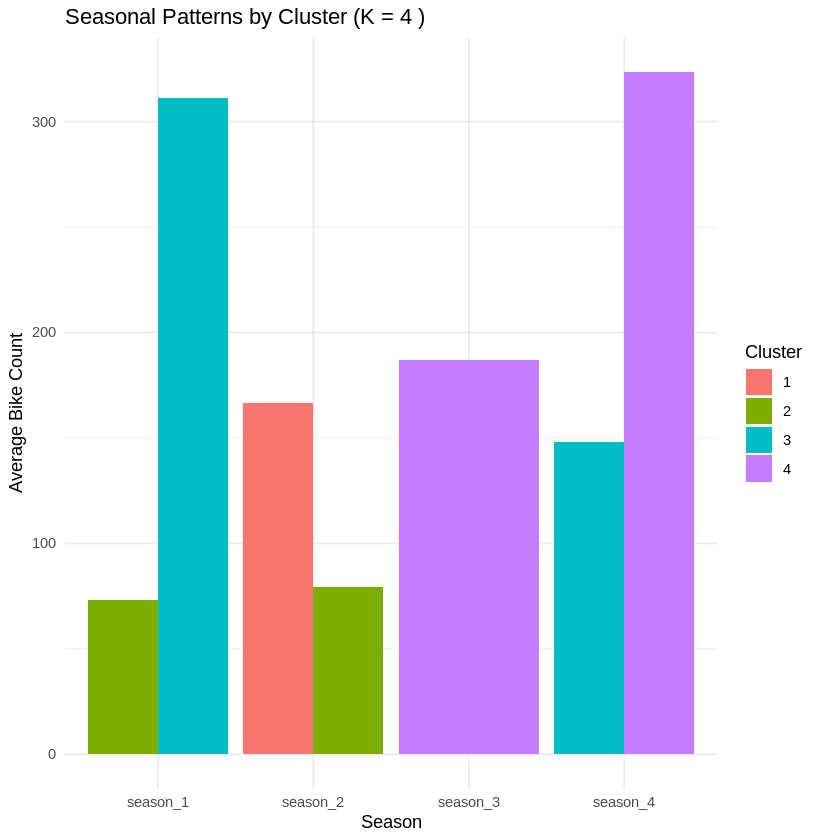

In [ ]:
perform_kmeans_analysis <- function(df, famd_result, k) {
  cat(paste("\n\nPerforming K-means clustering with K =", k, "...\n"))

  # Prepare FAMD score data
  famd_scores <- as.data.frame(famd_result$ind$coord)
  cluster_data <- famd_scores[, 1:min(10, ncol(famd_scores))]  # use first 10 dimensions as previous

  # Run k-means
  set.seed(123)
  kmeans_result <- kmeans(cluster_data, centers = k, nstart = 25, iter.max = 100)

  # Add cluster labels
  df$cluster <- kmeans_result$cluster
  famd_scores$cluster <- as.factor(kmeans_result$cluster)

  # 2D Visualization
  p1 <- ggplot(famd_scores, aes(x = Dim.1, y = Dim.2, color = cluster)) +
    geom_point(alpha = 0.6, size = 1.5) +
    scale_color_brewer(palette = "Set1", name = "Cluster") +
    ggtitle(paste("FAMD: Clustering Results (K =", k, ")")) +
    theme_minimal()
  print(p1)

  # Cluster profiles
  cat("\n\n📊 Analyzing cluster profiles...\n")
  cluster_profiles <- df %>%
    group_by(cluster) %>%
    summarise(
      n = n(),
      percentage = n() / nrow(df) * 100,
      avg_bikes = mean(cnt, na.rm = TRUE),
      sd_bikes = sd(cnt, na.rm = TRUE),
      avg_temp = mean(temp, na.rm = TRUE),
      avg_hum = mean(hum, na.rm = TRUE),
      peak_hour = as.numeric(names(which.max(table(hour)))),
      dominant_season = as.numeric(names(which.max(table(season)))),
      dominant_weather = as.numeric(names(which.max(table(weathersit))))
    ) %>%
    arrange(desc(avg_bikes))

  print(cluster_profiles)

  # Boxplot: Bike count by cluster
  p2 <- ggplot(df, aes(x = factor(cluster), y = cnt, fill = factor(cluster))) +
    geom_boxplot(alpha = 0.7) +
    labs(title = paste("Bike Count Distribution by Cluster (K =", k, ")"),
         x = "Cluster", y = "Bike Count") +
    theme_minimal() +
    theme(legend.position = "none")
  print(p2)

  # Hourly pattern
  hourly_patterns <- df %>%
    group_by(cluster, hour) %>%
    summarise(avg_bikes = mean(cnt, na.rm = TRUE), .groups = 'drop')

  p3 <- ggplot(hourly_patterns, aes(x = hour, y = avg_bikes, color = factor(cluster))) +
    geom_line(size = 1) +
    geom_point(size = 1) +
    labs(title = paste("Hourly Usage Patterns by Cluster (K =", k, ")"),
         x = "Hour of Day", y = "Average Bike Count", color = "Cluster") +
    theme_minimal()
  print(p3)

  # Seasonal pattern
  seasonal_patterns <- df %>%
    group_by(cluster, season) %>%
    summarise(avg_bikes = mean(cnt, na.rm = TRUE), .groups = 'drop')

  p4 <- ggplot(seasonal_patterns, aes(x = factor(season), y = avg_bikes, fill = factor(cluster))) +
    geom_bar(stat = "identity", position = "dodge") +
    labs(title = paste("Seasonal Patterns by Cluster (K =", k, ")"),
         x = "Season", y = "Average Bike Count", fill = "Cluster") +
    theme_minimal()
  print(p4)

  return(list(
    model = kmeans_result,
    cluster_profiles = cluster_profiles,
    plots = list(p1 = p1, p2 = p2, p3 = p3, p4 = p4)
  ))
}

# Run the function for K = 2 and K = 4
result_k1 <- perform_kmeans_analysis(df, famd_result, k = 2)
result_k2 <- perform_kmeans_analysis(df, famd_result, k = 4)



---



* **Part 4**: Cluster **Quality Validation**

In [ ]:
install.packages("fpc")
install.packages("clusterSim")

library(fpc)
library(clusterSim)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘modeltools’, ‘DEoptimR’, ‘mclust’, ‘flexmix’, ‘prabclus’, ‘diptest’, ‘robustbase’, ‘kernlab’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘pixmap’, ‘sp’, ‘RcppArmadillo’, ‘proxy’, ‘ade4’, ‘e1071’


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:plotly’:

    select


The following object is masked from ‘package:dplyr’:

    select






Evaluating existing K-means clustering with K = 2 ...


Warning message:
“There were 4 warnings in `summarise()`.
The first warning was:
ℹ In argument: `dominant_season = if ("season" %in% vars_present)
  as.numeric(names(which.max(table(season)))) else NA`.
ℹ In group 1: `cluster = 1`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.”


# A tibble: 2 × 10
  cluster     n percentage avg_bikes sd_bikes avg_temp avg_hum peak_hour
    <int> <int>      <dbl>     <dbl>    <dbl>    <dbl>   <dbl>     <dbl>
1       1  4091       48.7     195.     150.     0.657   0.649        17
2       2  4315       51.3      96.7     94.7    0.331   0.640         6
# ℹ 2 more variables: dominant_season <dbl>, dominant_weather <dbl>

Performing cluster quality validation...
  cluster size ave.sil.width
1       1 4091          0.29
2       2 4315          0.26
Average Silhouette Width: 0.276 
Calinski-Harabasz Index: 3282.37 
Davies-Bouldin Index: 1.598 
Performing cluster stability analysis (bootstrap)...
Cluster Stability Score: 0.599 


Evaluating existing K-means clustering with K = 4 ...


Warning message:
“There were 8 warnings in `summarise()`.
The first warning was:
ℹ In argument: `dominant_season = if ("season" %in% vars_present)
  as.numeric(names(which.max(table(season)))) else NA`.
ℹ In group 1: `cluster = 1`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 7 remaining warnings.”


# A tibble: 4 × 10
  cluster     n percentage avg_bikes sd_bikes avg_temp avg_hum peak_hour
    <int> <int>      <dbl>     <dbl>    <dbl>    <dbl>   <dbl>     <dbl>
1       1  1935       23.0     167.     142.     0.562   0.666        16
2       2  2214       26.3      73.7     67.7    0.276   0.576        22
3       3  2005       23.9     148.     130.     0.419   0.699         8
4       4  2252       26.8     191.     150.     0.700   0.644        13
# ℹ 2 more variables: dominant_season <dbl>, dominant_weather <dbl>

Performing cluster quality validation...
  cluster size ave.sil.width
1       1 1935          0.34
2       2 2214          0.41
3       3 2005          0.39
4       4 2252          0.41
Average Silhouette Width: 0.391 
Calinski-Harabasz Index: 4059.88 
Davies-Bouldin Index: 1.136 
Performing cluster stability analysis (bootstrap)...
Cluster Stability Score: 0.153 


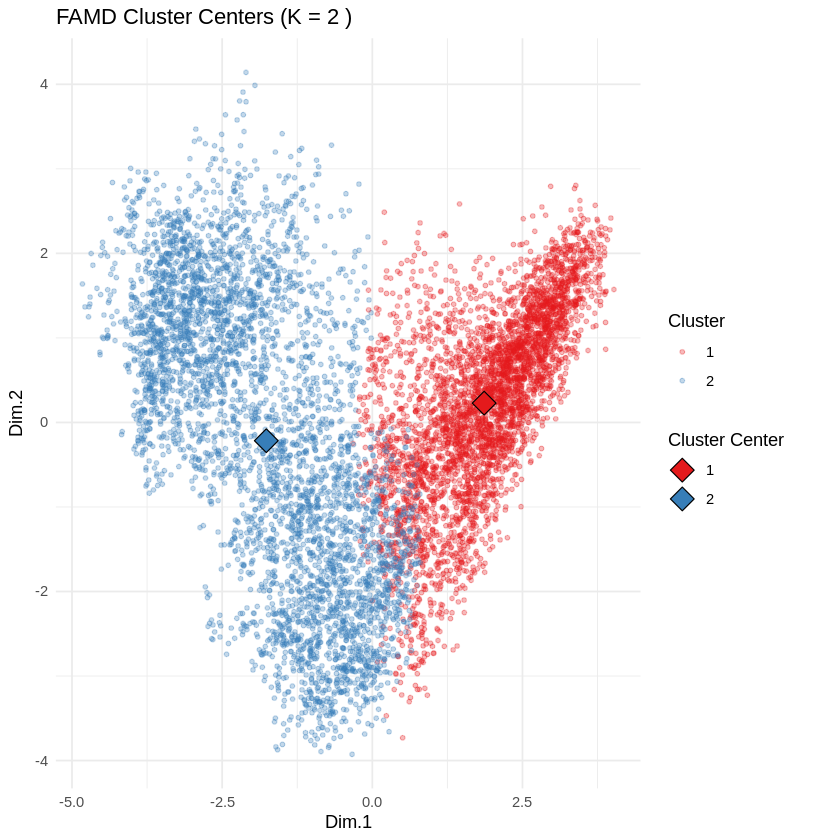

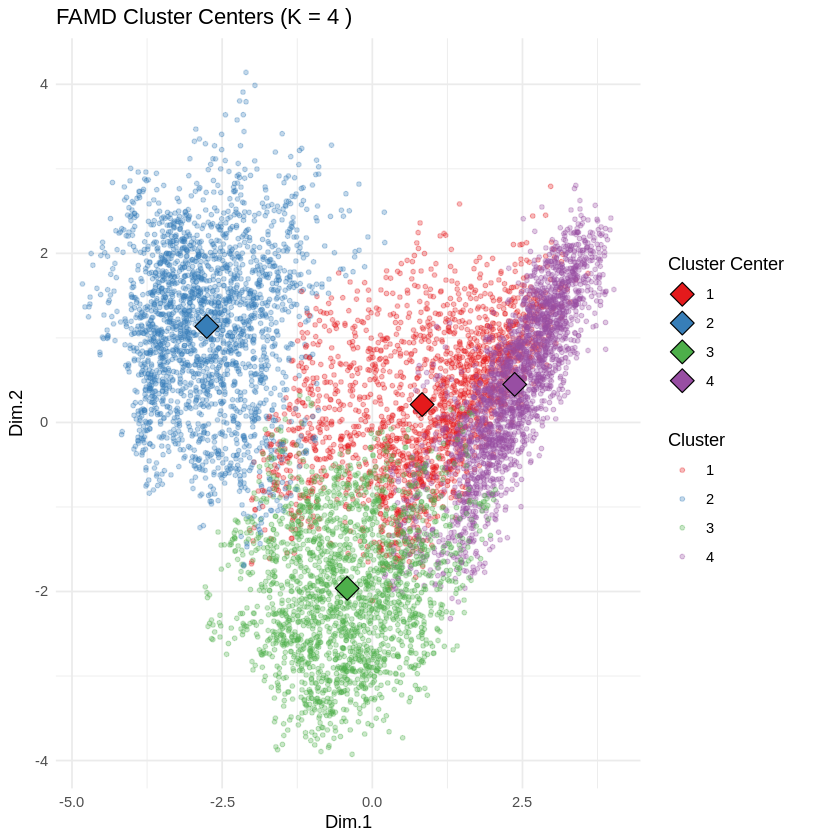

In [ ]:
evaluate_cluster_results <- function(df, famd_result, cluster_result, k) {
  cat(paste("\n\nEvaluating existing K-means clustering with K =", k, "...\n"))

  # Extract objects from previous results
  kmeans_result <- cluster_result$model
  famd_scores <- as.data.frame(famd_result$ind$coord)
  cluster_data <- famd_scores[, 1:min(5, ncol(famd_scores))]
  famd_scores$cluster <- as.factor(kmeans_result$cluster)
  df$cluster <- kmeans_result$cluster

  # Cluster Profile Summary
  vars_present <- names(df)

  cluster_profiles <- df %>%
    group_by(cluster) %>%
    summarise(
      n = n(),
      percentage = n() / nrow(df) * 100,
      avg_bikes = if ("cnt" %in% vars_present) mean(cnt, na.rm = TRUE) else NA,
      sd_bikes  = if ("cnt" %in% vars_present) sd(cnt, na.rm = TRUE) else NA,
      avg_temp  = if ("temp" %in% vars_present) mean(temp, na.rm = TRUE) else NA,
      avg_hum   = if ("hum" %in% vars_present) mean(hum, na.rm = TRUE) else NA,
      peak_hour = if ("hour" %in% vars_present) as.numeric(names(which.max(table(hour)))) else NA,
      dominant_season = if ("season" %in% vars_present) as.numeric(names(which.max(table(season)))) else NA,
      dominant_weather = if ("weathersit" %in% vars_present) as.numeric(names(which.max(table(weathersit)))) else NA
    )

  print(cluster_profiles)

  # Cluster Validation Metrics
  cat("\nPerforming cluster quality validation...\n")

  # 1. Silhouette
  sil <- silhouette(kmeans_result$cluster, dist(cluster_data))
  fviz_silhouette(sil) + ggtitle(paste("Silhouette Plot for K =", k))
  avg_sil_width <- mean(sil[, 3])
  cat(paste("Average Silhouette Width:", round(avg_sil_width, 3), "\n"))

  # 2. Calinski–Harabasz Index
  ch_index <- calinhara(cluster_data, kmeans_result$cluster)
  cat(paste("Calinski-Harabasz Index:", round(ch_index, 2), "\n"))

  # 3. Davies–Bouldin Index
  db_index <- index.DB(cluster_data, kmeans_result$cluster)$DB
  cat(paste("Davies-Bouldin Index:", round(db_index, 3), "\n"))

  # Cluster Stability (Bootstrap)
  cat("Performing cluster stability analysis (bootstrap)...\n")
  cluster_stability <- function(data, base_clusters, k, n_bootstrap = 10) {
    jaccard_similarities <- numeric(n_bootstrap)
    for(i in 1:n_bootstrap) {
      sample_indices <- sample(1:nrow(data), size = nrow(data) * 0.8, replace = TRUE)
      sample_data <- data[sample_indices, ]
      boot_clusters <- kmeans(sample_data, centers = k, nstart = 25)$cluster
      original_sample_clusters <- base_clusters[sample_indices]
      agreement <- mean(boot_clusters == original_sample_clusters)
      jaccard_similarities[i] <- agreement
    }
    mean(jaccard_similarities)
  }

  stability_score <- cluster_stability(cluster_data, kmeans_result$cluster, k)
  cat(paste("Cluster Stability Score:", round(stability_score, 3), "\n"))

  # Cluster Centers Visualization
  cluster_centers <- as.data.frame(kmeans_result$centers[, 1:2])

  # Assign cluster labels (1 to k)
  cluster_centers$cluster <- 1:k

  p1 <- ggplot() +
    geom_point(data = famd_scores, aes(x = Dim.1, y = Dim.2, color = cluster),
               alpha = 0.3, size = 1) +
    geom_point(data = cluster_centers, aes(x = Dim.1, y = Dim.2, fill = factor(cluster)),
               size = 5, shape = 23, color = "black") +
    scale_color_brewer(palette = "Set1", name = "Cluster") +
    scale_fill_brewer(palette = "Set1", name = "Cluster Center") +
    ggtitle(paste("FAMD Cluster Centers (K =", k, ")")) +
    theme_minimal()
  print(p1)

  # Return Results
  return(list(
    model = kmeans_result,
    sil_width = avg_sil_width,
    ch_index = ch_index,
    db_index = db_index,
    stability = stability_score,
    profiles = cluster_profiles,
    plots = list(cluster_center_plot = p1)
  ))
}

eval_k2 <- evaluate_cluster_results(df, famd_result, result_k1, k = 2)
eval_k4 <- evaluate_cluster_results(df, famd_result, result_k2, k = 4)